####======================================================
### **Homework Assignment 8**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing vertebral column data from *Vertebral_column_3C.dat* to examine relationships between biomechanical features and the orthopaedic patients' classes (disk hernia, normal, spondilolysthesis) (60 DH, 100 NO, 150 SL). The dataset contains 310 data points (rows) and has 7 features (columns including label). A Multi-Layer Perceptron (MLP) with 2 hidden layers was created. The neural network was trained with various numbers of epochs. The loss and classification error curves were plotted vs. number of epochs.

The following steps were performed:

1. Values for 6 independent variables/features (unnamed) and the class, *label*, were loaded into a DataFrame. The data was split into a training set and testing set (70/30). The X feature matrix was standardized using scaler.

2. Multi Layer Perceptron (MLP) Neural Network

    a) Created neural network with the following number of nodes, along 4 layers: 6 - 8 - 4 - 1

    b) Trained the NN on the data with varying number of epochs (2-100) and plotted the loss curve, the classification error curve, the confusion matrix, and the classification error.


#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [18]:
import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

import sklearn
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import plot_model

#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [19]:
# create dataframe (df) from the input file
df = pd.read_csv('Vertebral_column_3C.dat', sep = '\s+', header = None)

# check df columns for missing values
df.isnull().sum().to_frame().transpose()

,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0


In [20]:
# make X matrix and rename columns
X = df.iloc[:, :6].rename(columns = {0: 'f0', 1: 'f1', 2: 'f2', 3: 'f3', 4: 'f4', 5: 'f5'})

In [21]:
X

,f0,f1,f2,f3,f4,f5
0,63.03,22.55,39.61,40.48,98.67,-0.25
1,39.06,10.06,25.02,29.00,114.41,4.56
2,68.83,22.22,50.09,46.61,105.99,-3.53
3,69.30,24.65,44.31,44.64,101.87,11.21
4,49.71,9.65,28.32,40.06,108.17,7.92
...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25
306,53.94,20.72,29.22,33.22,114.37,-0.42
307,61.45,22.69,46.17,38.75,125.67,-2.71
308,45.25,8.69,41.58,36.56,118.55,0.21


In [22]:
# make y vector and map the labels to integers

# 0 - disk hernia       - DH
# 1 - spondilolysthesis - SL
# 2 - normal            - NO

y = df.iloc[:, 6:].rename(columns={6: 'label'})

mapping = {'DH': 0, 'SL': 1, 'NO': 2}
y['label'] = y['label'].map(mapping)

y

,label
0,0
1,0
2,0
3,0
4,0
...,...
305,2
306,2
307,2
308,2


In [23]:
# get count of labels in y
y['label'].value_counts()

,count
label,
1,150
2,100
0,60


In [24]:
# split data into a training set (70%) and a testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 305, stratify = y)

In [25]:
# get counts of labels in y_train and y_test
print(y_train['label'].value_counts())
print(y_test['label'].value_counts())

label
1    105
2     70
0     42
Name: count, dtype: int64
label
1    45
2    30
0    18
Name: count, dtype: int64


In [26]:
# standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# transform the y vectors to be 1D arrays
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [28]:
# class label names
class_labels = ["DISK HERNIA", "SPONDILOLYSTHESIS", "NORMAL"]

#### ====================================================
#### MULTI LAYER PERCEPTRON (MLP)
#### ======================================================

In [29]:
# list of the epoch values and hidden layer sizes

epochs_list = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

layer_sizes = [6, 8, 4, 1]

In [30]:
# create and compile an MLP model with a given list of layer sizes
def create_mlp(layer_sizes):

    model = keras.Sequential([
        keras.layers.Dense(layer_sizes[1], activation='relu', input_shape=(layer_sizes[0],)),
        keras.layers.Dense(layer_sizes[2], activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [31]:
# return results from a model training on a given number of epochs
def train_and_evaluate(epochs, layer_sizes, X_train, y_train, X_test, y_test):

    model = create_mlp(layer_sizes)
    history = model.fit(X_train, y_train, epochs=epochs, verbose=0, batch_size=32, validation_data=(X_test, y_test))

    train_loss = history.history['loss'][-1]
    test_loss = history.history['val_loss'][-1]

    y_pred = (model.predict(X_test) > 0.5).astype(int)
    test_error = 1 - accuracy_score(y_test, y_pred)

    return train_loss, test_loss, test_error

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


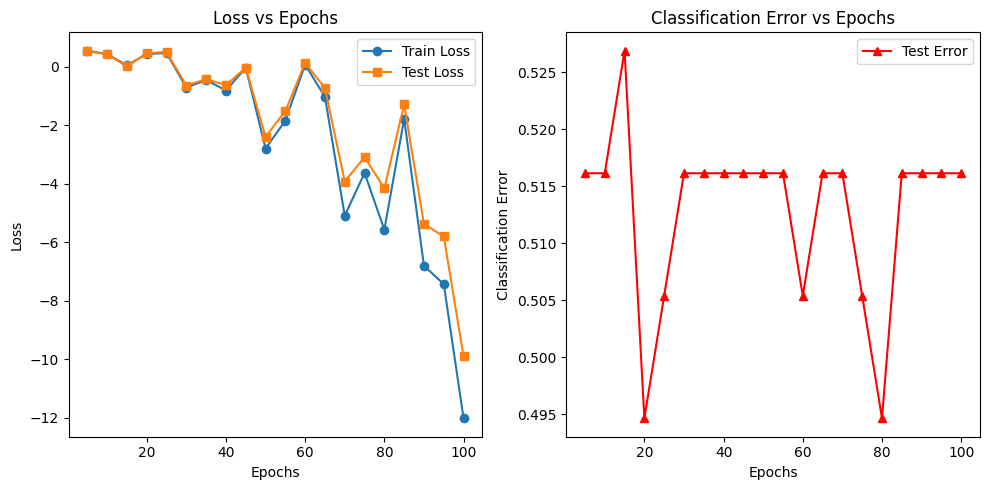

In [32]:
train_losses, test_losses, test_errors = [], [], []

for epochs in epochs_list:
    train_loss, test_loss, test_error = train_and_evaluate(epochs, layer_sizes, X_train, y_train, X_test, y_test)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_errors.append(test_error)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_list, test_losses, marker='s', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.subplot(1, 2, 2)
plt.plot(epochs_list, test_errors, marker='^', color='r', label='Test Error')
plt.xlabel('Epochs')
plt.ylabel('Classification Error')
plt.legend()
plt.title('Classification Error vs Epochs')

plt.tight_layout()
plt.show()


In [ ]:

#plot_model(model, show_shapes=True, show_layer_names=True)
